# 05 Capacity Baseline Forecasting

## 작업 목표

- 공식 직접 예측 target은 `capacity_ah`
- `predicted_soh = predicted_capacity_ah / initial_capacity`로 SoH를 파생
- Persistence, MovingAverage, LinearTrend baseline을 실행.
- Pre-EOL과 Post-EOL 구간을 분리해서 평가.
- capacity와 파생 SoH 기준 metric을 모두 계산.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
INPUT_PATH = (
    PROJECT_ROOT / "data" / "processed" / "paraquet"
    / "battery_cycles_analysis.parquet"
)
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PRIMARY_TARGET = "capacity_ah"
MODEL_FAMILY = "baseline"
EOL_THRESHOLD = 0.80
WINDOW = 20

In [6]:
# 데이터 로드 및 검증

df = pd.read_parquet(INPUT_PATH)

required_columns = [
    "cell_id", "cycle", "capacity_ah",
    "initial_capacity", "soh",
    "life_stage", "is_modeling_cycle",
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]
assert not missing_columns, f"필수 컬럼 누락: {missing_columns}"

# 모델링 대상으로 확정된 표준 cycle만 사용합니다.
series_df = (
    df.loc[df["is_modeling_cycle"]]
    .sort_values("cycle")
    .reset_index(drop=True)
)

initial_values = (
    series_df["initial_capacity"]
    .dropna()
    .unique()
)
assert len(initial_values) == 1

INITIAL_CAPACITY = float(initial_values[0])

assert len(series_df) == 868
assert series_df["cycle"].is_monotonic_increasing
assert series_df["capacity_ah"].notna().all()
assert (series_df["capacity_ah"] > 0).all()

print("전체 데이터:", df.shape)
print("모델링 데이터:", series_df.shape)
print("Initial capacity:", INITIAL_CAPACITY)
display(series_df.head())
display(series_df["life_stage"].value_counts())

전체 데이터: (886, 40)
모델링 데이터: (868, 40)
Initial capacity: 1.1364220858837624


,cell_id,cycle,source_file,source_fingerprint,file_order,file_date,local_cycle,row_count,test_time_min,test_time_max,...,initial_capacity,soh,eol_threshold,eol_confirmation_cycles,eol_cycle,is_censored,rul,rul_clipped,post_eol,life_stage
0,CS2_35,1,CS2_35_8_17_10.xlsx,2cc2d274ee67d047a85c28c2d41ae41d0262e484769cff...,1,2010-08-17,1,1091,10.000849,13154.420547,...,1.136422,1.001793,0.8,5,546,False,545,545,False,pre_eol
1,CS2_35,2,CS2_35_8_18_10.xlsx,e993803166ecf6206a0fc69b51e92d387c17107bed6e91...,2,2010-08-18,1,383,30.000929,12989.361424,...,1.136422,1.001149,0.8,5,546,False,544,544,False,pre_eol
2,CS2_35,3,CS2_35_8_19_10.xlsx,2297a5cb31e22dc2531af93aa769aa04d0725e52ec47c4...,3,2010-08-19,1,383,30.000173,12968.469391,...,1.136422,1.000932,0.8,5,546,False,543,543,False,pre_eol
3,CS2_35,4,CS2_35_8_30_10.xlsx,98f0a93a538f072b31abe3d448593285b9e1a5b87870a9...,4,2010-08-30,1,382,30.000576,12959.534197,...,1.136422,1.000590,0.8,5,546,False,542,542,False,pre_eol
4,CS2_35,5,CS2_35_8_30_10.xlsx,98f0a93a538f072b31abe3d448593285b9e1a5b87870a9...,4,2010-08-30,2,381,12989.568327,25915.579596,...,1.136422,0.995536,0.8,5,546,False,541,541,False,pre_eol


life_stage
pre_eol     541
post_eol    326
eol           1
Name: count, dtype: int64[pyarrow]

In [7]:
# 평가지표 및 예측 함수
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = denominator > 0

    if not valid.any():
        return 0.0

    return float(
        np.mean(
            np.abs(y_true[valid] - y_pred[valid])
            / denominator[valid]
        ) * 100
    )


# 마지막 관측값을 미래 전체에 반복합니다.
def forecast_persistence(train_values, horizon):
    return np.repeat(train_values[-1], horizon)


# 최근 window개 관측값의 평균을 반복합니다.
def forecast_moving_average(train_values, horizon, window):
    return np.repeat(
        train_values[-window:].mean(),
        horizon,
    )


# 최근 window개 관측값의 선형 추세를 외삽합니다.
def forecast_linear_trend(train_values, horizon, window):
    recent_values = train_values[-window:]
    x_train = np.arange(len(recent_values))

    slope, intercept = np.polyfit(
        x_train,
        recent_values,
        deg=1,
    )

    x_future = np.arange(
        len(recent_values),
        len(recent_values) + horizon,
    )

    return slope * x_future + intercept

In [8]:
# baseline 실험 함수

def run_baseline_experiment(
    experiment_name,
    experiment_df,
    train_ratio,
):
    data = (
        experiment_df
        .sort_values("cycle")
        .reset_index(drop=True)
    )

    split_index = int(len(data) * train_ratio)

    train_df = data.iloc[:split_index].copy()
    test_df = data.iloc[split_index:].copy()

    assert len(train_df) > WINDOW
    assert len(test_df) > 0
    assert train_df["cycle"].max() < test_df["cycle"].min()

    train_values = train_df[PRIMARY_TARGET].to_numpy(float)
    test_capacity = test_df[PRIMARY_TARGET].to_numpy(float)
    test_cycles = test_df["cycle"].to_numpy(int)

    horizon = len(test_df)
    train_end_cycle = int(train_df["cycle"].max())

    prediction_map = {
        "Persistence": forecast_persistence(
            train_values, horizon
        ),
        "MovingAverage": forecast_moving_average(
            train_values, horizon, WINDOW
        ),
        "LinearTrend": forecast_linear_trend(
            train_values, horizon, WINDOW
        ),
    }

    forecast_frames = []

    for model_name, raw_predictions in prediction_map.items():
        # Capacity는 음수가 될 수 없으므로 0 이상으로 제한합니다.
        predictions = np.clip(
            raw_predictions,
            a_min=0.0,
            a_max=None,
        )

        forecast_frames.append(
            pd.DataFrame(
                {
                    "experiment_name": experiment_name,
                    "cell_id": data["cell_id"].iloc[0],
                    "model_family": MODEL_FAMILY,
                    "primary_target": PRIMARY_TARGET,
                    "model_name": model_name,
                    "cycle": test_cycles,
                    "y_true_capacity": test_capacity,
                    "y_pred_capacity_raw": raw_predictions,
                    "y_pred_capacity": predictions,
                    "y_true_soh": (
                        test_capacity / INITIAL_CAPACITY
                    ),
                    "y_pred_soh": (
                        predictions / INITIAL_CAPACITY
                    ),
                    "initial_capacity": INITIAL_CAPACITY,
                    "train_end_cycle": train_end_cycle,
                    "horizon_index": np.arange(1, horizon + 1),
                }
            )
        )

    forecasts = pd.concat(
        forecast_frames,
        ignore_index=True,
    )

    metric_rows = []

    for model_name, group in forecasts.groupby("model_name"):
        true_capacity = group["y_true_capacity"].to_numpy()
        pred_capacity = group["y_pred_capacity"].to_numpy()
        true_soh = group["y_true_soh"].to_numpy()
        pred_soh = group["y_pred_soh"].to_numpy()

        metric_rows.append(
            {
                "experiment_name": experiment_name,
                "model_family": MODEL_FAMILY,
                "primary_target": PRIMARY_TARGET,
                "model_name": model_name,
                "capacity_mae": mae(
                    true_capacity, pred_capacity
                ),
                "capacity_rmse": rmse(
                    true_capacity, pred_capacity
                ),
                "capacity_smape": smape(
                    true_capacity, pred_capacity
                ),
                "soh_mae": mae(true_soh, pred_soh),
                "soh_rmse": rmse(true_soh, pred_soh),
                "soh_smape": smape(true_soh, pred_soh),
                "n": len(group),
                "train_end_cycle": train_end_cycle,
            }
        )

    metrics = (
        pd.DataFrame(metric_rows)
        .sort_values("capacity_mae")
        .reset_index(drop=True)
    )

    return train_df, test_df, forecasts, metrics

In [9]:
# Pre-EOL 실험

pre_eol_df = (
    series_df.loc[
        series_df["life_stage"] == "pre_eol"
    ]
    .sort_values("cycle")
    .reset_index(drop=True)
)

(
    pre_train_df,
    pre_test_df,
    pre_forecasts,
    pre_metrics,
) = run_baseline_experiment(
    experiment_name="pre_eol_70_split",
    experiment_df=pre_eol_df,
    train_ratio=0.70,
)

print("Train:", len(pre_train_df))
print("Test:", len(pre_test_df))
print("Train end:", pre_train_df["cycle"].max())
display(pre_metrics)

Train: 378
Test: 163
Train end: 381


,experiment_name,model_family,primary_target,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n,train_end_cycle
0,pre_eol_70_split,baseline,capacity_ah,MovingAverage,0.028366,0.040093,2.970140,0.024961,0.035280,2.970140,163,381
1,pre_eol_70_split,baseline,capacity_ah,Persistence,0.028659,0.040455,2.999884,0.025218,0.035598,2.999884,163,381
2,pre_eol_70_split,baseline,capacity_ah,LinearTrend,0.050528,0.065454,5.183008,0.044462,0.057597,5.183008,163,381


In [10]:
(
    post_train_df,
    post_test_df,
    post_forecasts,
    post_metrics,
) = run_baseline_experiment(
    experiment_name="post_eol_75_split",
    experiment_df=series_df,
    train_ratio=0.75,
)

print("Train:", len(post_train_df))
print("Test:", len(post_test_df))
print("Train end:", post_train_df["cycle"].max())
display(post_metrics)

Train: 651
Test: 217
Train end: 657


,experiment_name,model_family,primary_target,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n,train_end_cycle
0,post_eol_75_split,baseline,capacity_ah,LinearTrend,0.030896,0.036043,6.016708,0.027187,0.031716,6.016708,217,657
1,post_eol_75_split,baseline,capacity_ah,Persistence,0.212946,0.257113,32.591385,0.187382,0.226248,32.591385,217,657
2,post_eol_75_split,baseline,capacity_ah,MovingAverage,0.255115,0.292993,37.393852,0.224490,0.257820,37.393852,217,657


In [16]:
def plot_experiment(
    train_df,
    test_df,
    forecasts,
    title,
):
    fig, axes = plt.subplots(
        1, 2,
        figsize=(16, 5),
        constrained_layout=True,
    )

    axes[0].plot(
        train_df["cycle"],
        train_df["capacity_ah"],
        color="gray",
        label="Train",
    )
    axes[0].plot(
        test_df["cycle"],
        test_df["capacity_ah"],
        color="black",
        linewidth=2,
        label="Actual",
    )

    for model_name, group in forecasts.groupby("model_name"):
        axes[0].plot(
            group["cycle"],
            group["y_pred_capacity"],
            label=model_name,
        )

    axes[0].axvline(
        train_df["cycle"].max(),
        color="red",
        linestyle="--",
        label="Forecast start",
    )
    axes[0].set_title(f"{title} - Capacity")
    axes[0].set_xlabel("Cycle")
    axes[0].set_ylabel("Capacity (Ah)")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(
        test_df["cycle"],
        test_df["soh"],
        color="black",
        linewidth=2,
        label="Actual",
    )

    for model_name, group in forecasts.groupby("model_name"):
        axes[1].plot(
            group["cycle"],
            group["y_pred_soh"],
            label=model_name,
        )

    axes[1].axhline(
        EOL_THRESHOLD,
        color="red",
        linestyle="--",
        label="EOL threshold",
    )
    axes[1].set_title(f"{title} - Derived SoH")
    axes[1].set_xlabel("Cycle")
    axes[1].set_ylabel("SoH")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.show()

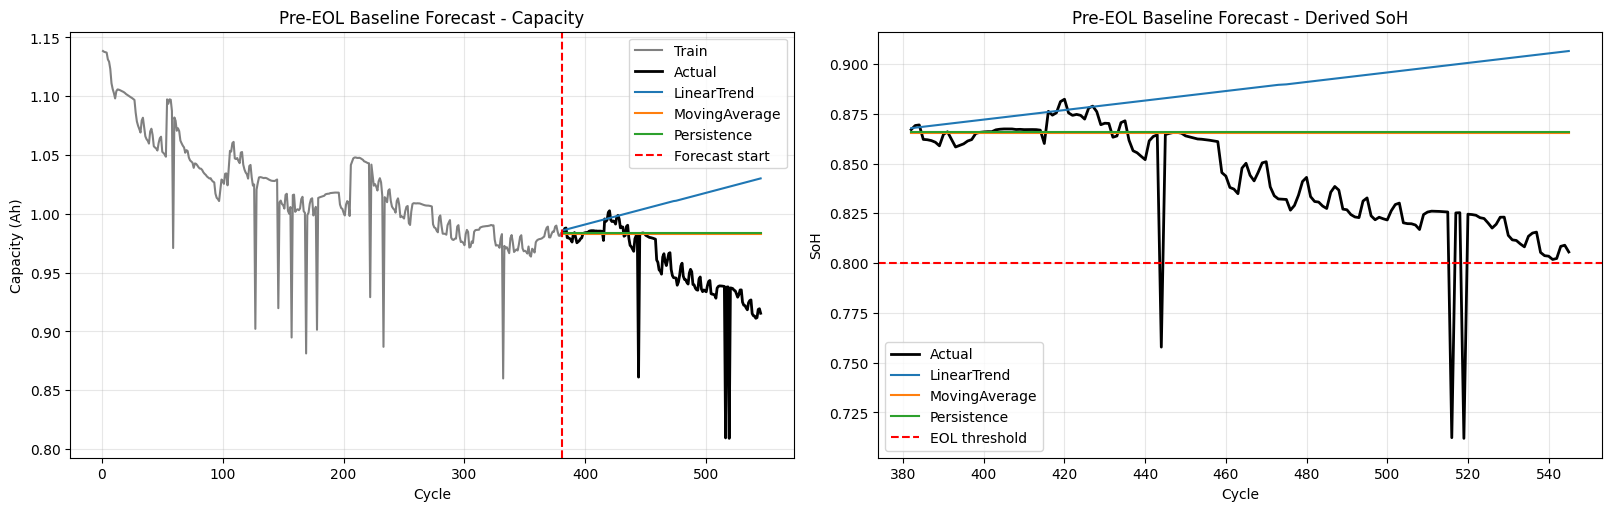

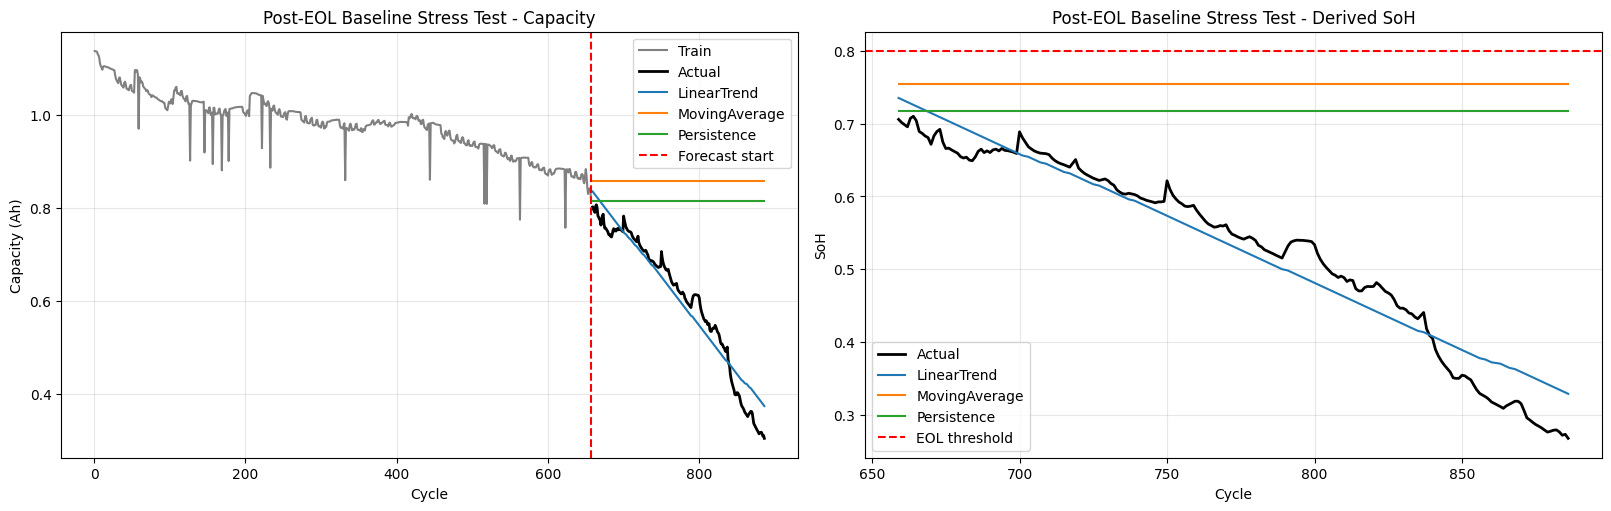

In [17]:
# Stress Test는 모델이 정상적인 예측조건보다 훨씬 어려운 상황에서 얼마나 버티는지 확인하는 실험
# 모델의 장기 열화 추적 한계를 확인하는 실험
plot_experiment(
    pre_train_df,
    pre_test_df,
    pre_forecasts,
    "Pre-EOL Baseline Forecast",
)

plot_experiment(
    post_train_df,
    post_test_df,
    post_forecasts,
    "Post-EOL Baseline Stress Test",
)

In [18]:
all_forecasts = pd.concat(
    [pre_forecasts, post_forecasts],
    ignore_index=True,
)

all_metrics = pd.concat(
    [pre_metrics, post_metrics],
    ignore_index=True,
).sort_values(
    ["experiment_name", "capacity_mae"]
).reset_index(drop=True)

assert len(pre_forecasts) == 163 * 3
assert len(post_forecasts) == 217 * 3
assert len(all_forecasts) == 1140
assert len(all_metrics) == 6

assert set(all_forecasts["model_family"]) == {"baseline"}
assert (all_forecasts["y_pred_capacity"] >= 0).all()

assert not all_forecasts.duplicated(
    ["experiment_name", "model_name", "cycle"]
).any()

display(all_metrics)

,experiment_name,model_family,primary_target,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n,train_end_cycle
0,post_eol_75_split,baseline,capacity_ah,LinearTrend,0.030896,0.036043,6.016708,0.027187,0.031716,6.016708,217,657
1,post_eol_75_split,baseline,capacity_ah,Persistence,0.212946,0.257113,32.591385,0.187382,0.226248,32.591385,217,657
2,post_eol_75_split,baseline,capacity_ah,MovingAverage,0.255115,0.292993,37.393852,0.224490,0.257820,37.393852,217,657
3,pre_eol_70_split,baseline,capacity_ah,MovingAverage,0.028366,0.040093,2.970140,0.024961,0.035280,2.970140,163,381
4,pre_eol_70_split,baseline,capacity_ah,Persistence,0.028659,0.040455,2.999884,0.025218,0.035598,2.999884,163,381
5,pre_eol_70_split,baseline,capacity_ah,LinearTrend,0.050528,0.065454,5.183008,0.044462,0.057597,5.183008,163,381


In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_frames = {
    "baseline_capacity_forecasts_pre_eol": pre_forecasts,
    "baseline_capacity_metrics_pre_eol": pre_metrics,
    "baseline_capacity_forecasts_post_eol": post_forecasts,
    "baseline_capacity_metrics_post_eol": post_metrics,
    "baseline_capacity_forecasts_all": all_forecasts,
    "baseline_capacity_metrics_all": all_metrics,
}

for file_name, frame in output_frames.items():
    csv_path = OUTPUT_DIR / f"{file_name}.csv"
    frame.to_csv(csv_path, index=False)

    # Forecast 결과는 파이프라인용 Parquet도 저장합니다.
    if "forecasts" in file_name:
        parquet_path = OUTPUT_DIR / f"{file_name}.parquet"
        frame.to_parquet(parquet_path, index=False)

print("Forecast rows:", len(all_forecasts))
print("Metric rows:", len(all_metrics))
print("저장 위치:", OUTPUT_DIR)

Forecast rows: 1140
Metric rows: 6
저장 위치: /Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/outputs
